In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import datetime

In [ ]:
# Load the dataset
file_path = "/content/NCRB_CII_2017_State_Table-9A.3.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 25 columns):
 #   Column                                                                                                                                                         Non-Null Count  Dtype 
---  ------                                                                                                                                                         --------------  ----- 
 0   S. No (Col.1)                                                                                                                                                  39 non-null     object
 1   Category (Col.2)                                                                                                                                               39 non-null     object
 2   State/UT (Col.3)                                                                                                                                

(None,
   S. No (Col.1) Category (Col.2)   State/UT (Col.3)  Personal Revenge (Col.4)  \
 0             1            State     Andhra Pradesh                        24   
 1             2            State  Arunachal Pradesh                         0   
 2             3            State              Assam                       246   
 3             4            State              Bihar                        12   
 4             5            State       Chhattisgarh                         8   
 
    Anger (Col.5)  Fraud (Col.6)  Extortion (Col.7)  Causing Disrepute (Col.8)  \
 0              5            537                 65                          0   
 1              0              0                  0                          0   
 2             83             48                 65                         40   
 3              5            397                  3                          0   
 4              3             47                  4                         29   
 
    P

In [ ]:
# Renaming columns for better readability
df.rename(columns={
    "S. No (Col.1)": "S_No",
    "Category (Col.2)": "Category",
    "State/UT (Col.3)": "State_UT",
    "Personal Revenge (Col.4)": "Personal_Revenge",
    "Anger (Col.5)": "Anger",
    "Fraud (Col.6)": "Fraud",
    "Extortion (Col.7)": "Extortion",
    "Causing Disrepute (Col.8)": "Causing_Disrepute",
    "Prank (Col.9)": "Prank",
    "Sexual Exploitation (Col.10)": "Sexual_Exploitation",
    "Political Motives (Col.11)": "Political_Motives",
    "Terrorist Activities (Col.12= Col.13+Col.14+Col.15)": "Terrorist_Activities",
    "Terrorist Activities - Terrorist Recruitment (Col.13)": "Terrorist_Recruitment",
    "Terrorist Activities - Terrorist Funding (Col.14)": "Terrorist_Funding",
    "Terrorist Activities - Others (Col.15)": "Terrorist_Others",
    "Inciting Hate against Country (Col.16)": "Inciting_Hate",
    "Disrupt Public Service (Col.17)": "Disrupt_Public_Service",
    "Sale Purchase Illegal Drugs (Col.18)": "Illegal_Drug_Sale",
    "Developing own Business (Col.19)": "Developing_Business",
    "Spreading Piracy (Col.20)": "Spreading_Piracy",
    "Psycho or Pervert (Col.21)": "Psycho_Pervert",
    "Steal Information (Col.22)": "Steal_Information",
    "Abetment to Suicide (Col.23)": "Abetment_to_Suicide",
    "Others (Col.24)": "Others",
    "Total (Col.25=Col.1+Col.2+Col.3+Col.4Col.5+Col.6+Col.7+Col.8+Col.9+Col.10+Col.11+Col.12+Col.15+Col.16+Col.17+Col.18+Col.19+Col.20+Col.21+Col.22+Col.23+Col.24": "Total"
}, inplace=True)

# Checking the updated column names
df.head()


,S_No,Category,State_UT,Personal_Revenge,Anger,Fraud,Extortion,Causing_Disrepute,Prank,Sexual_Exploitation,...,Inciting_Hate,Disrupt_Public_Service,Illegal_Drug_Sale,Developing_Business,Spreading_Piracy,Psycho_Pervert,Steal_Information,Abetment_to_Suicide,Others,Total
0,1,State,Andhra Pradesh,24,5,537,65,0,0,61,...,0,1,0,0,1,0,0,0,217,931
1,2,State,Arunachal Pradesh,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2,3,State,Assam,246,83,48,65,40,40,217,...,2,0,0,0,0,0,3,0,322,1120
3,4,State,Bihar,12,5,397,3,0,0,16,...,0,0,0,0,0,0,0,0,0,433
4,5,State,Chhattisgarh,8,3,47,4,29,18,16,...,1,0,0,0,0,0,0,0,42,171


In [ ]:
# Summary statistics of numerical columns
df.describe()


,Personal_Revenge,Anger,Fraud,Extortion,Causing_Disrepute,Prank,Sexual_Exploitation,Political_Motives,Terrorist_Activities,Terrorist_Recruitment,...,Inciting_Hate,Disrupt_Public_Service,Illegal_Drug_Sale,Developing_Business,Spreading_Piracy,Psycho_Pervert,Steal_Information,Abetment_to_Suicide,Others,Total
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,...,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,48.307692,54.923077,939.461538,69.692308,77.076923,24.692308,112.307692,10.692308,8.461538,0.076923,...,15.846154,4.230769,0.615385,12.000000,6.923077,1.307692,0.769231,0.384615,288.923077,1676.615385
std,141.568684,162.074282,2752.158204,206.788877,226.473234,75.638042,323.590641,30.805121,25.196957,0.269953,...,46.531562,12.278483,1.941451,33.938024,20.591752,3.974616,2.253203,1.349764,831.728586,4832.658115
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,7.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,11.500000
50%,7.000000,3.000000,48.000000,7.000000,4.000000,0.000000,16.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,176.000000
75%,19.000000,11.500000,364.000000,18.000000,29.500000,5.000000,52.000000,7.500000,2.000000,0.000000,...,6.000000,2.000000,0.000000,7.500000,2.000000,0.000000,0.500000,0.000000,134.500000,772.000000
max,628.000000,714.000000,12213.000000,906.000000,1002.000000,321.000000,1460.000000,139.000000,110.000000,1.000000,...,206.000000,55.000000,8.000000,156.000000,90.000000,17.000000,10.000000,5.000000,3756.000000,21796.000000


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


,0


<ipython-input-7-d90ac2d2ed73>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_sorted["Total"], y=df_sorted["State_UT"], palette="viridis")


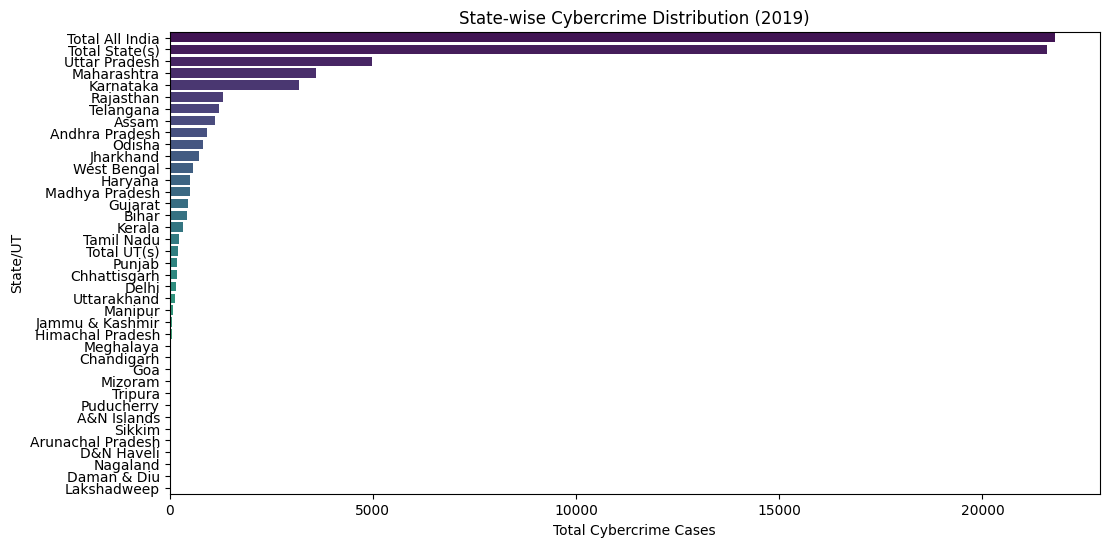

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sorting states by total cybercrime count for better visualization
df_sorted = df.sort_values(by="Total", ascending=False)

# Plotting the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=df_sorted["Total"], y=df_sorted["State_UT"], palette="viridis")
plt.xlabel("Total Cybercrime Cases")
plt.ylabel("State/UT")
plt.title("State-wise Cybercrime Distribution (2019)")
plt.show()


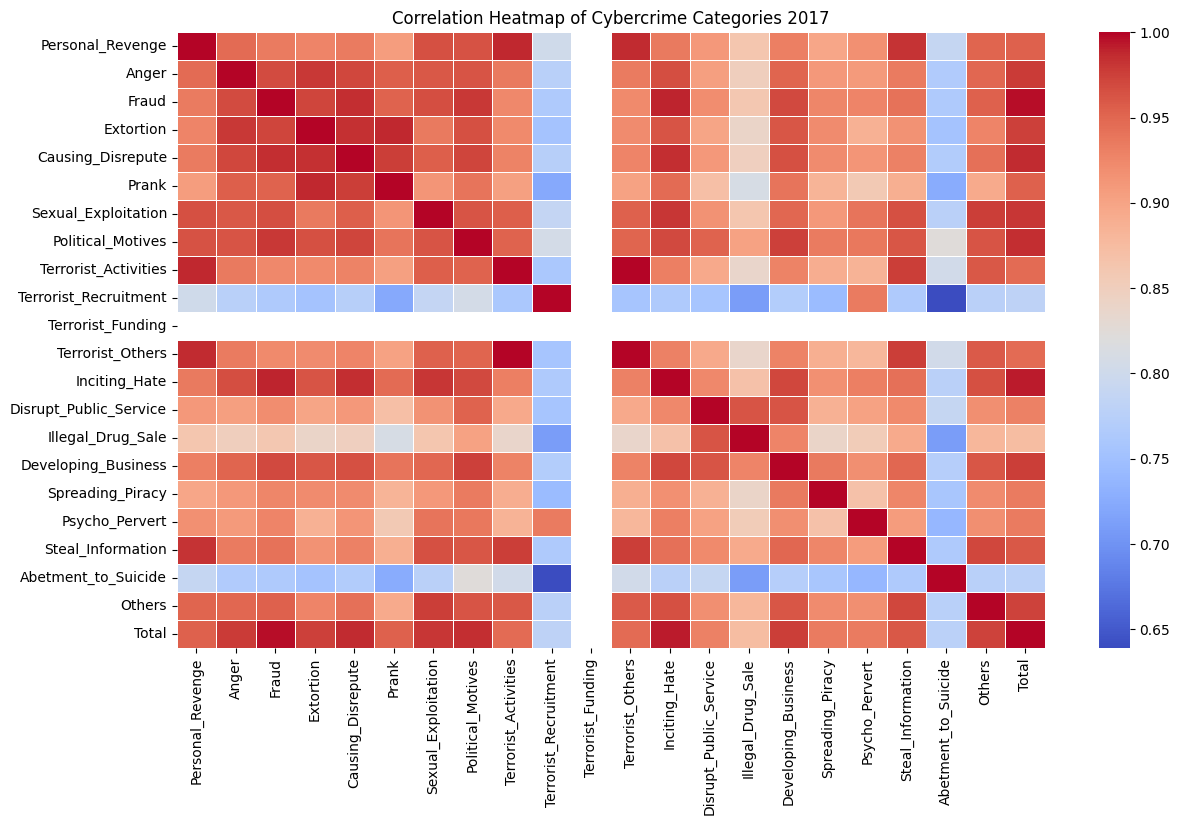

In [ ]:
# Compute correlation matrix
plt.figure(figsize=(14, 8))
corr_matrix = df.iloc[:, 3:].corr()  # Exclude non-numeric columns

# Plot heatmap
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Cybercrime Categories 2017")
plt.show()


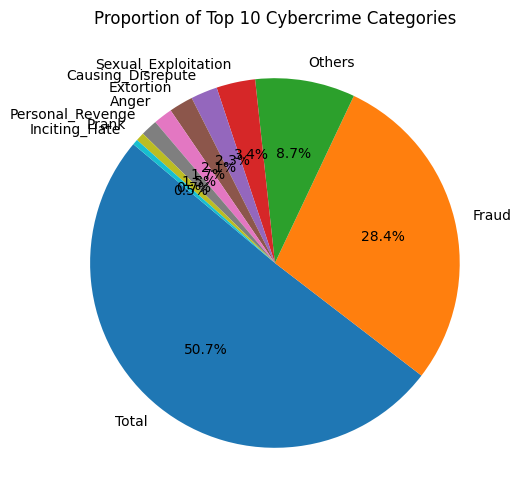

In [ ]:
crime_sums = df.iloc[:, 3:].sum().sort_values(ascending=False)

# Plot pie chart for top 10 cybercrime categories
plt.figure(figsize=(10, 6))
crime_sums[:10].plot(kind="pie", autopct="%1.1f%%", cmap="tab10", startangle=140)
plt.ylabel("")
plt.title("Proportion of Top 10 Cybercrime Categories")
plt.show()

<Figure size 1400x600 with 0 Axes>

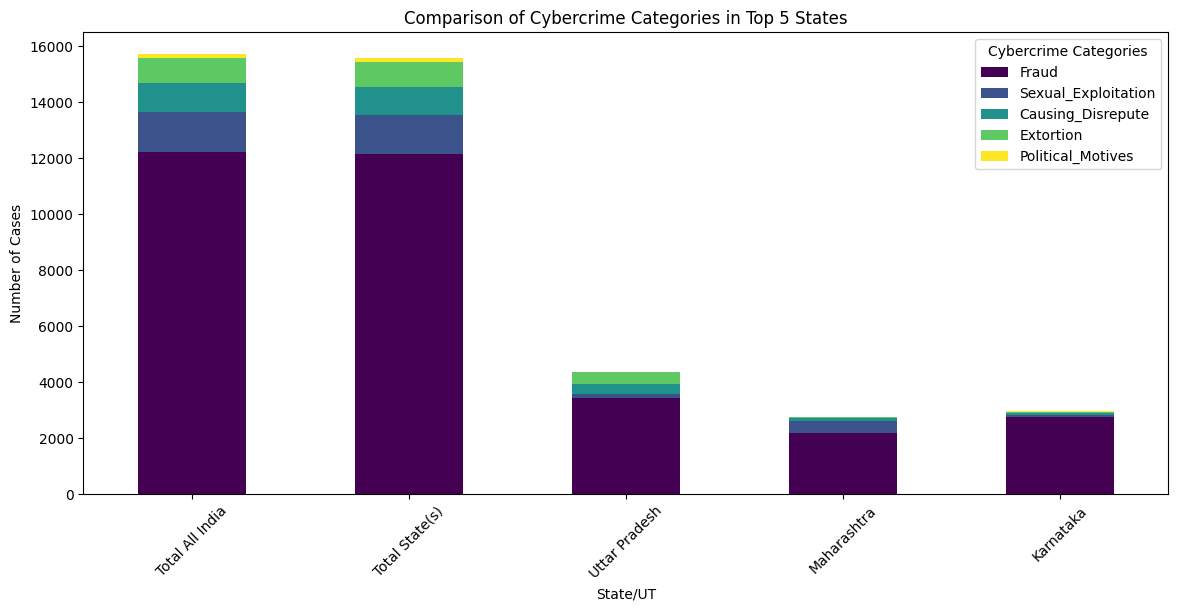

In [ ]:
# Selecting top 5 states with highest cybercrimes for visualization clarity
top_states = df.nlargest(5, "Total")

# Plot stacked bar chart
plt.figure(figsize=(14, 6))
top_states.set_index("State_UT")[["Fraud", "Sexual_Exploitation", "Causing_Disrepute", "Extortion", "Political_Motives"]].plot(kind="bar", stacked=True, colormap="viridis", figsize=(14,6))

plt.xlabel("State/UT")
plt.ylabel("Number of Cases")
plt.title("Comparison of Cybercrime Categories in Top 5 States")
plt.legend(title="Cybercrime Categories")
plt.xticks(rotation=45)
plt.show()


<Figure size 1000x600 with 0 Axes>

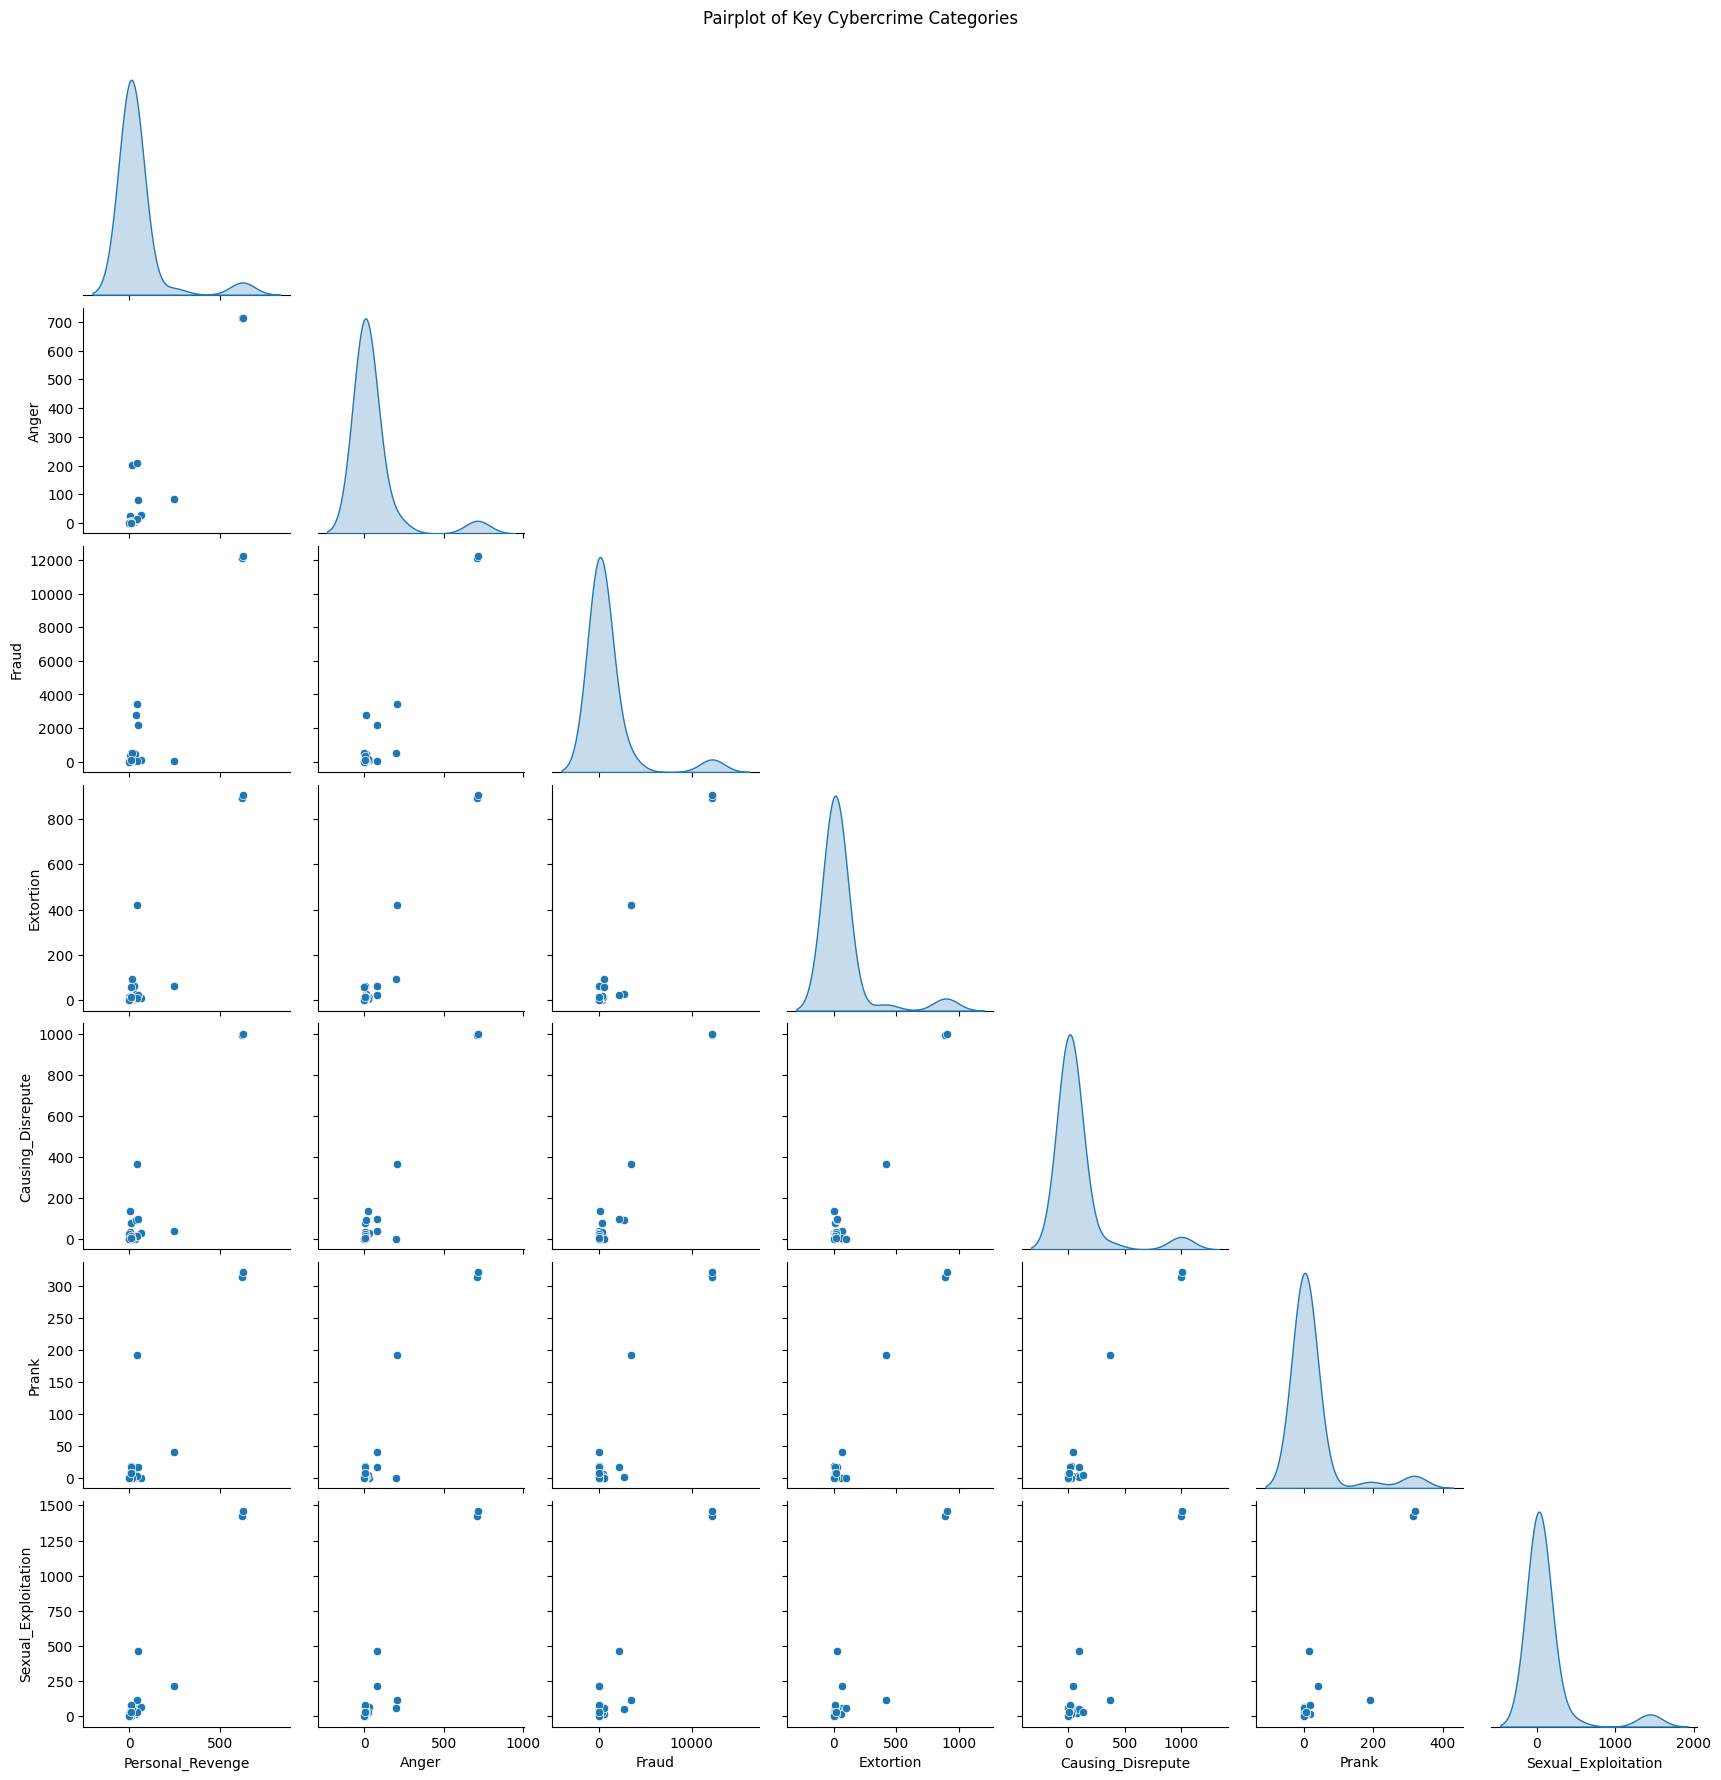

In [ ]:
# Pairplot to visualize relationships between different cybercrime categories
plt.figure(figsize=(10, 6))
sns.pairplot(df.iloc[:, 3:10], diag_kind="kde", corner=True)  # Selecting a subset for clarity
plt.suptitle("Pairplot of Key Cybercrime Categories", y=1.02)
plt.show()


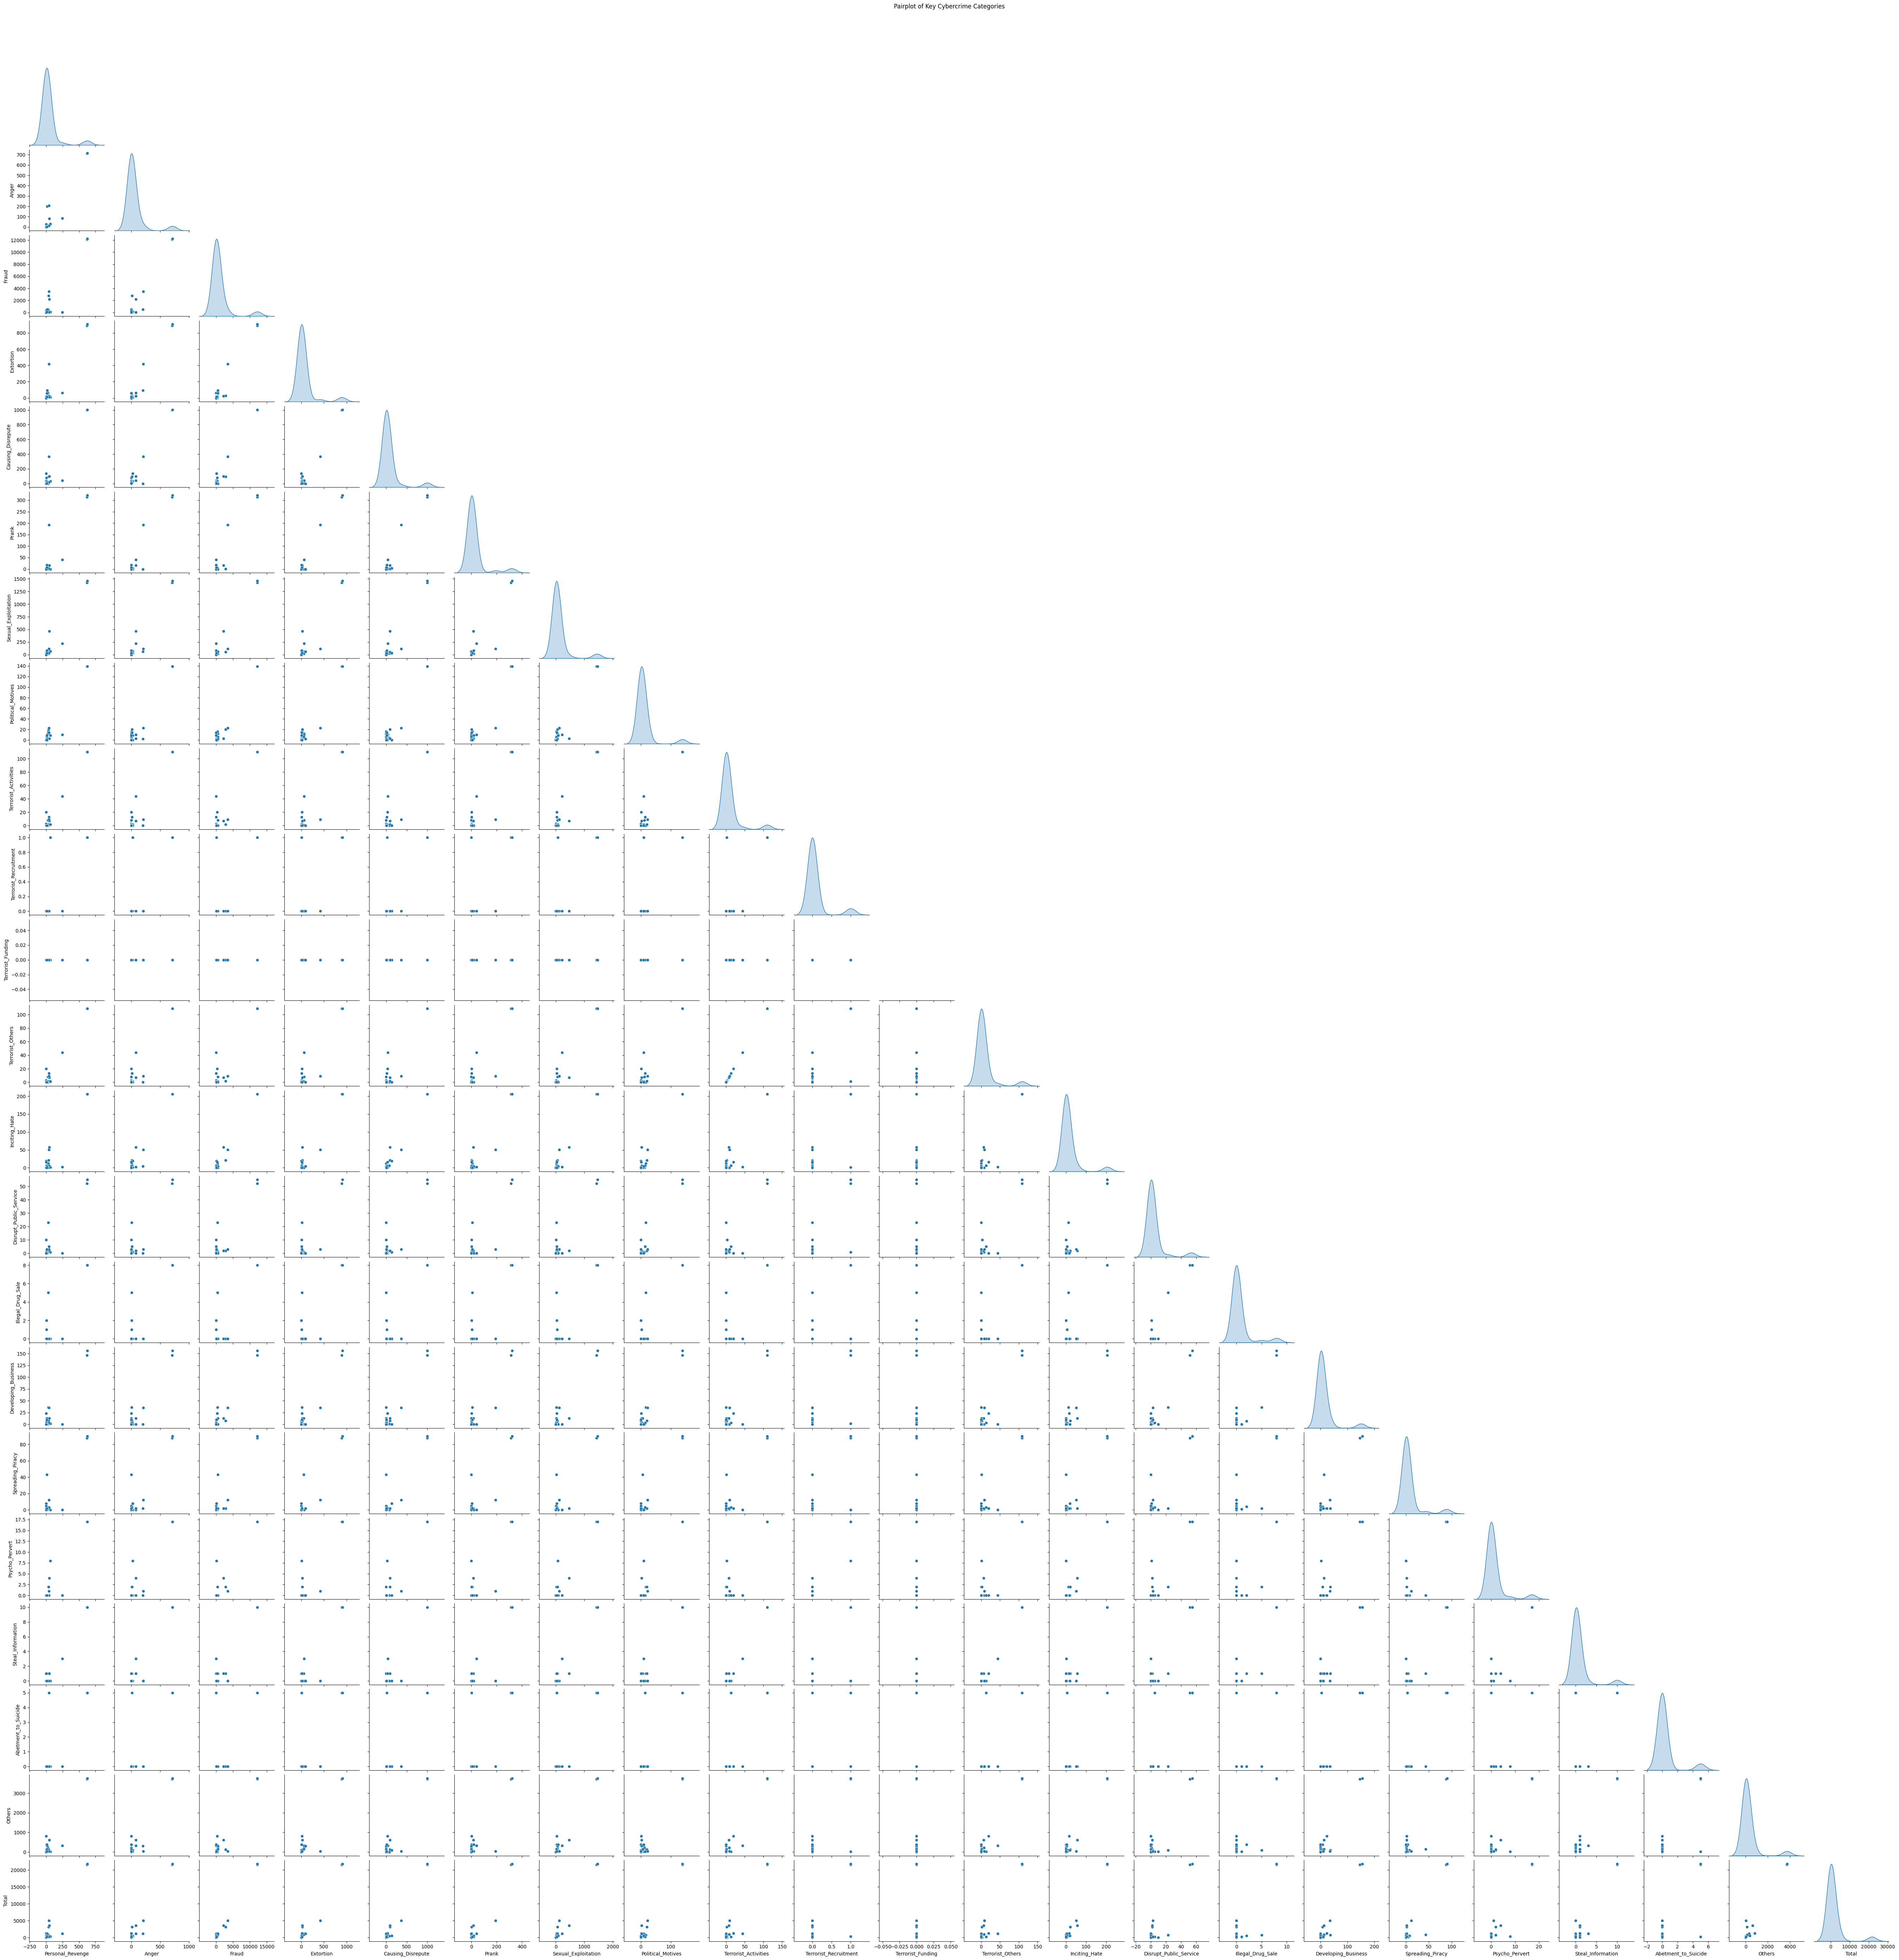

In [ ]:
# Convert all numeric columns to proper numeric format (ignoring errors to avoid conversion issues)
df_numeric = df.iloc[:, 3:].apply(pd.to_numeric, errors="coerce")

# Dropping any rows with NaN values (if conversion failed for some columns)
df_numeric_cleaned = df_numeric.dropna()

# Retry the pairplot after cleaning
sns.pairplot(df_numeric_cleaned, diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Key Cybercrime Categories", y=1.02)
plt.show()
